In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical, plot_model
import os

import warnings
warnings.filterwarnings("ignore")

# cone

In [5]:
data = []
result = []


for r, d, f in os.walk("D:\\Cone&Popsicle\\Cone vs Popsicle\\Cone"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0   # 🔥 normalization

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([0, 1]) 

# popsicle

In [6]:
for r, d, f in os.walk("D:\\Cone&Popsicle\\Cone vs Popsicle\\Popsicle"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([1, 0])

In [7]:
data = np.array(data)
result = np.array(result)

print("Data shape:", data.shape)      
print("Result shape:", result.shape)

Data shape: (600, 128, 128, 3)
Result shape: (600, 2)


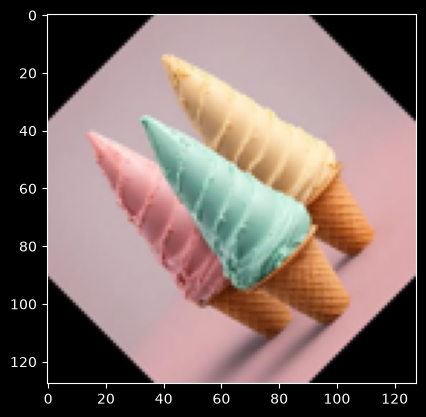

In [8]:
plt.imshow(data[55]) # taking element(photo) in the data from the 60 th index 

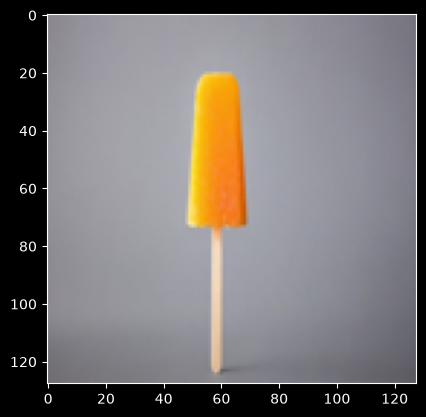

In [9]:
plt.imshow(data[302]) 

In [10]:
x_train, x_test, y_train, y_test = train_test_split(data, result, test_size=0.2, shuffle=True, random_state=42)

In [11]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,621,922 (128.26 MB)

 Trainable params: 33,621,730 (128.26 MB)

 Non-trainable params: 192 (768.00 B)

None


In [12]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [13]:
x_train.shape

(480, 128, 128, 3)

In [14]:
y_train.shape

(480, 2)

In [24]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    verbose=1,
    validation_data=(x_test, y_test))

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.5167 - val_loss: 16.4690
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 93s 11s/step - accuracy: 0.9979 - loss: 0.0108 - val_accuracy: 0.5167 - val_loss: 17.4740
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.9979 - loss: 0.0021 - val_accuracy: 0.5167 - val_loss: 17.3157
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 92s 12s/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.5167 - val_loss: 16.0839
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 86s 10s/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.5167 - val_loss: 13.8518
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 107s 13s/step - accuracy: 0.9979 - loss: 0.0265 - val_accuracy: 0.5167 - val_loss: 13.4040
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.5167 - val_loss: 16.0005
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 102s 12s/step - accuracy: 0.9979 - loss: 0.0244 - val_accuracy: 0.5167 - val_loss: 

In [25]:
score = model.evaluate(x_test, y_test, batch_size=64)
print("\nTest accuracy: %.1f%%" % (100.0 * score[1]))

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 765ms/step - accuracy: 0.6000 - loss: 15.6217

Test accuracy: 60.0%


In [15]:
from PIL import Image

img_path = r"D:\\Cone&Popsicle\\Cone vs Popsicle\\Cone\\Cone (28).jpg"
img = Image.open(img_path)
img = img.resize((128,128))
img = np.array(img) / 255.0   # 🔥 same preprocessing

img = np.expand_dims(img, axis=0)  # shape (1,128,128,3)

prediction = model.predict(img)
pred_class = np.argmax(prediction)

if pred_class == 0:
    print("Prediction: Cone")
else:
    print("Prediction:  Popsicle")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
Prediction: Cone
